In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_predict_50k.csv',
 'placement_dataset.csv',
 'placement_predict_50k Dataset (1).csv',
 'age_insurance.csv',
 '2520030358 _Experiment 4.ipynb',
 'placement_predict_50k_adjusted.csv',
 'Experiment5_2520030358.ipynb',
 'simple_placement_dataset.csv',
 'WineQT.csv',
 'Experiment_4_2520030358.ipynb',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'student_data.csv',
 'iris_dataset.csv']

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

Dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Decision Tree ---
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



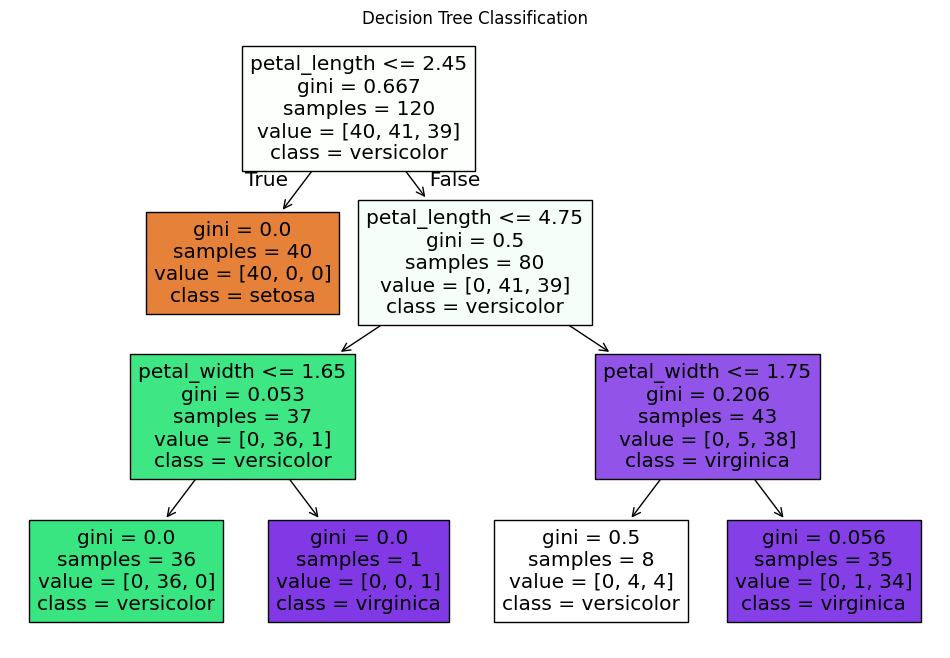


--- Random Forest ---
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Random Forest Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

--- Model Accuracy Comparison ---
Decision Tree Accuracy : 1.0
Random Forest Accuracy : 1.0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load dataset
data = pd.read_csv("/content/drive/MyDrive/Colab/iris_dataset.csv")

print("Dataset:")
print(data.head())

# 2. Separate input and output
X = data.drop("species", axis=1)
y = data["species"]

# 3. Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# DECISION TREE
# ==============================

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_prediction)

print("\n--- Decision Tree ---")
print("Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, dt_prediction))

# Display Decision Tree
plt.figure(figsize=(12, 8))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    filled=True
)

plt.title("Decision Tree Classification")
plt.show()


# ==============================
# RANDOM FOREST
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("\n--- Random Forest ---")
print("Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, rf_prediction))


# ==============================
# CONFUSION MATRICES
# ==============================

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_prediction))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_prediction))


# ==============================
# ACCURACY COMPARISON
# ==============================

print("\n--- Model Accuracy Comparison ---")
print("Decision Tree Accuracy :", dt_accuracy)
print("Random Forest Accuracy :", rf_accuracy)